# Simple RNN for Time Series Forecasting — Jena Climate Dataset

This notebook builds a **Simple RNN** (`SimpleRNN`, i.e. a vanilla recurrent layer — no gates like LSTM/GRU) to forecast temperature using the **Jena Climate dataset**, a real weather time series (10-minute interval measurements from a weather station in Jena, Germany, 2009–2016).

This is the same task and dataset as the LSTM version, with only the recurrent layer swapped out, so the two can be compared directly.

**Steps covered:**
1. Import libraries
2. Download and load the dataset
3. Explore and visualize the data
4. Preprocess (normalize, create windowed sequences)
5. Build the Simple RNN model
6. Compile and train the model
7. Evaluate on test data
8. Plot loss curves and forecast vs actual values


## 1. Import Libraries

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Download and Load the Dataset

`tf.keras.utils.get_file` downloads and caches the Jena Climate CSV (zipped) directly from TensorFlow's storage bucket — no manual upload needed.

In [2]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True
)

# extract=True unzips into a sibling "<fname>_extracted" directory rather than
# giving us the CSV path directly, so we search for the .csv file inside it.
extracted_dir = zip_path.replace('.csv.zip', '_extracted')
csv_candidates = glob.glob(os.path.join(extracted_dir, '**', '*.csv'), recursive=True)

if not csv_candidates:
    # fallback: some environments extract next to the zip file instead
    csv_candidates = glob.glob(os.path.join(os.path.dirname(zip_path), '*.csv'))

csv_path = csv_candidates[0]
print("Found CSV at:", csv_path)

df = pd.read_csv(csv_path)
print("Dataset shape:", df.shape)
df.head()


13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found CSV at: /root/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv
Dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### Select the Feature of Interest

The dataset records 14 different weather variables every 10 minutes. We'll focus on **temperature (`T (degC)`)** and resample to hourly readings to keep training fast.

In [3]:
# Keep 1 reading per hour (every 6th row, since data is recorded every 10 minutes)
df_hourly = df[5::6]

temp = df_hourly['T (degC)']
temp.index = pd.to_datetime(df_hourly['Date Time'], format='%d.%m.%Y %H:%M:%S')

print("Hourly samples:", len(temp))
temp.head()


Hourly samples: 70091


,T (degC)
Date Time,
2009-01-01 01:00:00,-8.05
2009-01-01 02:00:00,-8.88
2009-01-01 03:00:00,-8.81
2009-01-01 04:00:00,-9.05
2009-01-01 05:00:00,-9.63


## 3. Visualize the Time Series

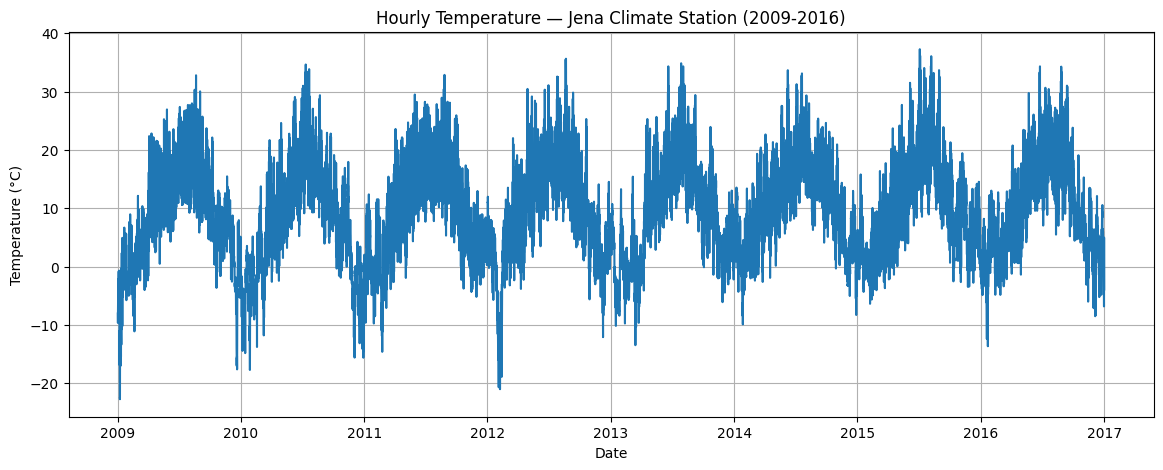

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(temp.index, temp.values)
plt.title('Hourly Temperature — Jena Climate Station (2009-2016)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


## 4. Preprocess the Data

Steps:
1. Split into train / validation / test sets chronologically (no shuffling — order matters for time series).
2. Normalize using statistics from the training set only.
3. Convert to supervised windows: use the past `WINDOW_SIZE` hours to predict the next hour's temperature.

In [5]:
values = temp.values.astype('float32').reshape(-1, 1)

n = len(values)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_data = values[:train_end]
val_data = values[train_end:val_end]
test_data = values[val_end:]

# Normalize using training mean/std
train_mean = train_data.mean()
train_std = train_data.std()

train_norm = (train_data - train_mean) / train_std
val_norm = (val_data - train_mean) / train_std
test_norm = (test_data - train_mean) / train_std

print("Train size:", len(train_norm))
print("Validation size:", len(val_norm))
print("Test size:", len(test_norm))


Train size: 49063
Validation size: 14018
Test size: 7010


In [6]:
WINDOW_SIZE = 24   # use past 24 hours
HORIZON = 1         # predict 1 hour ahead
BATCH_SIZE = 64

def make_dataset(data, window_size=WINDOW_SIZE, horizon=HORIZON, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data[:-horizon],
        targets=data[window_size:],
        sequence_length=window_size,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size
    )
    return ds

train_ds = make_dataset(train_norm, shuffle=True)
val_ds = make_dataset(val_norm)
test_ds = make_dataset(test_norm)

for batch_x, batch_y in train_ds.take(1):
    print("Input batch shape:", batch_x.shape)   # (batch, window_size, 1)
    print("Target batch shape:", batch_y.shape)  # (batch, 1)


Input batch shape: (64, 24, 1)
Target batch shape: (64, 1)


## 5. Build the Simple RNN Model

Architecture:
- **SimpleRNN layer**: a vanilla recurrent layer (no input/forget/output gates like LSTM) that learns temporal patterns across the 24-hour input window
- **Dropout**: regularization
- **Dense layers**: map RNN output to a single forecasted value

Note: `SimpleRNN` has far fewer parameters per unit than `LSTM` (no gating), and is more prone to vanishing gradients on longer sequences — worth watching for in the training curves.

In [7]:
RNN_UNITS = 64

model = Sequential([
    SimpleRNN(RNN_UNITS, input_shape=(WINDOW_SIZE, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # regression output (predicted temperature, normalized)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile and Train the Model

In [8]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

EPOCHS = 10

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.0215 - mae: 0.1024 - val_loss: 0.0078 - val_mae: 0.0628
Epoch 2/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.0124 - mae: 0.0809 - val_loss: 0.0077 - val_mae: 0.0611
Epoch 3/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0119 - mae: 0.0790 - val_loss: 0.0078 - val_mae: 0.0619
Epoch 4/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - loss: 0.0117 - mae: 0.0782 - val_loss: 0.0073 - val_mae: 0.0584
Epoch 5/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0115 - mae: 0.0779 - val_loss: 0.0086 - val_mae: 0.0655
Epoch 6/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 0.0114 - mae: 0.0773 - val_loss: 0.0077 - val_mae: 0.0622
Epoch 7/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 0.0111 - mae: 0.0766 - val_loss: 0.0081 - val_mae: 0.0642


## 7. Evaluate on Test Data

In [9]:
test_loss, test_mae = model.evaluate(test_ds, verbose=0)
print(f"Test Loss (MSE, normalized): {test_loss:.4f}")
print(f"Test MAE (normalized): {test_mae:.4f}")

# Convert normalized MAE back to degrees C for interpretability
test_mae_degC = test_mae * train_std
print(f"Test MAE (degrees C): {test_mae_degC:.4f}")


Test Loss (MSE, normalized): 0.0071
Test MAE (normalized): 0.0586
Test MAE (degrees C): 0.5073


## 8. Plot Training History

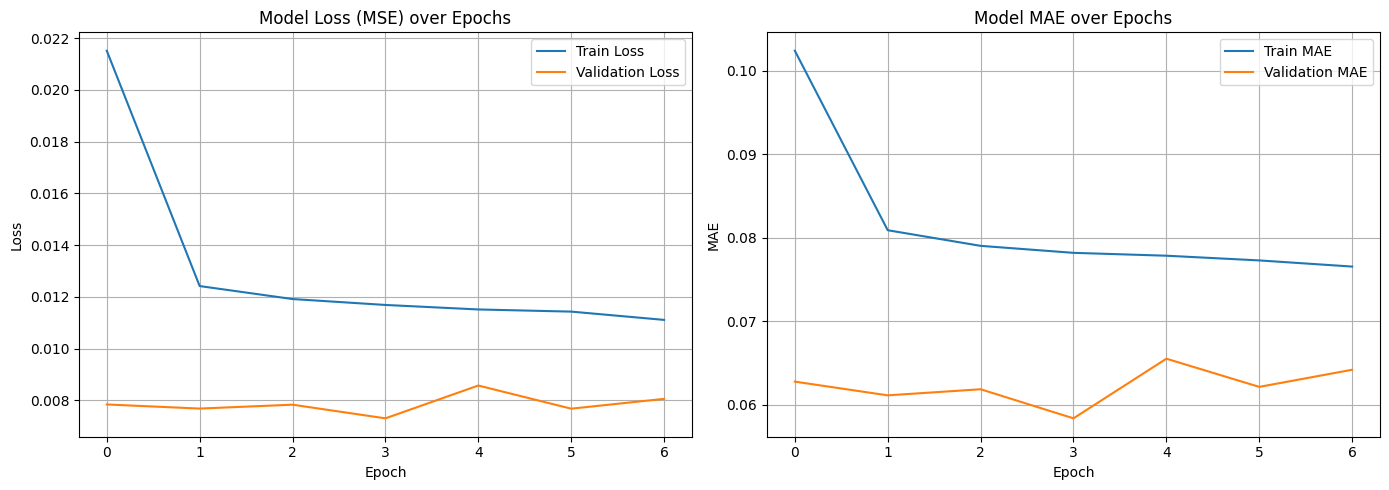

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 9. Forecast vs Actual — Visual Comparison

Test MAE: 0.507 °C
Test RMSE: 0.728 °C


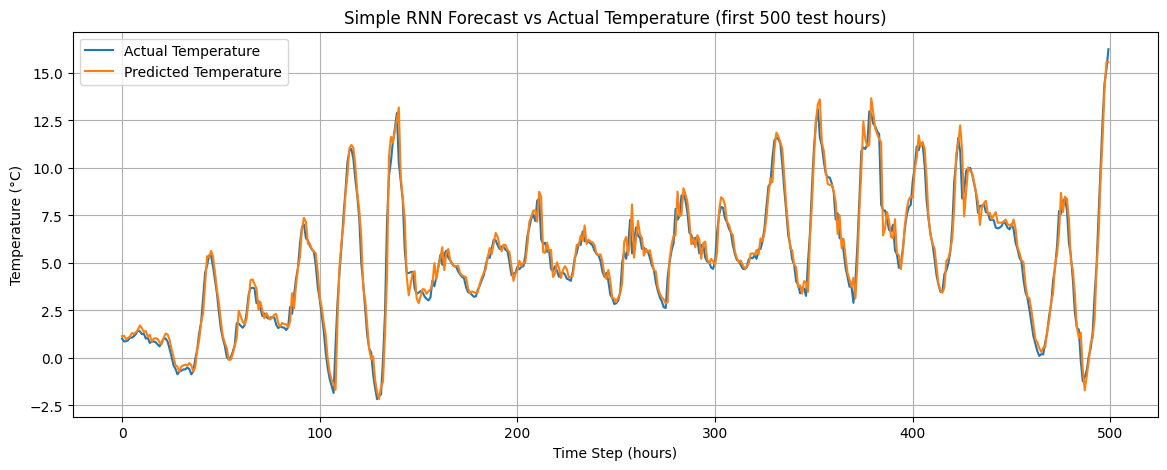

In [11]:
# Gather predictions and true values from the test set
y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    preds = model.predict(batch_x, verbose=0)
    y_true.extend(batch_y.numpy().flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# De-normalize back to actual temperature (°C)
y_true_degC = y_true * train_std + train_mean
y_pred_degC = y_pred * train_std + train_mean

mae = mean_absolute_error(y_true_degC, y_pred_degC)
rmse = np.sqrt(mean_squared_error(y_true_degC, y_pred_degC))
print(f"Test MAE: {mae:.3f} °C")
print(f"Test RMSE: {rmse:.3f} °C")

plt.figure(figsize=(14, 5))
plt.plot(y_true_degC[:500], label='Actual Temperature')
plt.plot(y_pred_degC[:500], label='Predicted Temperature')
plt.title('Simple RNN Forecast vs Actual Temperature (first 500 test hours)')
plt.xlabel('Time Step (hours)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()
